In [1]:
import numpy as np
import pandas as pd

In [2]:
## load the dataset
df = pd.read_csv("../data/telecom_churn_data.csv")

In [3]:
df.head()

,mobile_number,circle_id,loc_og_t2o_mou,std_og_t2o_mou,loc_ic_t2o_mou,last_date_of_month_6,last_date_of_month_7,last_date_of_month_8,last_date_of_month_9,arpu_6,...,sachet_3g_9,fb_user_6,fb_user_7,fb_user_8,fb_user_9,aon,aug_vbc_3g,jul_vbc_3g,jun_vbc_3g,sep_vbc_3g
0,7000842753,109,0.0,0.0,0.0,6/30/2014,7/31/2014,8/31/2014,9/30/2014,197.385,...,0,1.0,1.0,1.0,NaN,968,30.4,0.0,101.20,3.58
1,7001865778,109,0.0,0.0,0.0,6/30/2014,7/31/2014,8/31/2014,9/30/2014,34.047,...,0,NaN,1.0,1.0,NaN,1006,0.0,0.0,0.00,0.00
2,7001625959,109,0.0,0.0,0.0,6/30/2014,7/31/2014,8/31/2014,9/30/2014,167.690,...,0,NaN,NaN,NaN,1.0,1103,0.0,0.0,4.17,0.00
3,7001204172,109,0.0,0.0,0.0,6/30/2014,7/31/2014,8/31/2014,9/30/2014,221.338,...,0,NaN,NaN,NaN,NaN,2491,0.0,0.0,0.00,0.00
4,7000142493,109,0.0,0.0,0.0,6/30/2014,7/31/2014,8/31/2014,9/30/2014,261.636,...,0,0.0,NaN,NaN,NaN,1526,0.0,0.0,0.00,0.00


In [4]:
df.tail()

,mobile_number,circle_id,loc_og_t2o_mou,std_og_t2o_mou,loc_ic_t2o_mou,last_date_of_month_6,last_date_of_month_7,last_date_of_month_8,last_date_of_month_9,arpu_6,...,sachet_3g_9,fb_user_6,fb_user_7,fb_user_8,fb_user_9,aon,aug_vbc_3g,jul_vbc_3g,jun_vbc_3g,sep_vbc_3g
99994,7001548952,109,0.0,0.0,0.0,6/30/2014,7/31/2014,8/31/2014,9/30/2014,18.471,...,0,NaN,NaN,NaN,NaN,3199,0.00,0.00,0.00,0.0
99995,7000607688,109,0.0,0.0,0.0,6/30/2014,7/31/2014,8/31/2014,9/30/2014,112.201,...,0,NaN,NaN,NaN,NaN,2052,0.00,0.00,0.00,0.0
99996,7000087541,109,0.0,0.0,0.0,6/30/2014,7/31/2014,8/31/2014,9/30/2014,229.187,...,0,1.0,NaN,NaN,NaN,185,0.00,0.00,0.00,0.0
99997,7000498689,109,0.0,0.0,0.0,6/30/2014,7/31/2014,8/31/2014,9/30/2014,322.991,...,0,1.0,1.0,1.0,1.0,478,1445.74,1151.03,1173.18,0.0
99998,7001905007,109,0.0,0.0,0.0,6/30/2014,7/31/2014,8/31/2014,9/30/2014,687.065,...,0,1.0,NaN,NaN,NaN,751,0.00,0.00,0.00,0.0


In [5]:
df.shape

(99999, 226)

In [6]:
##avg of 6th and 7th month
df['avg_rech_amt_6_7'] = (df['total_rech_amt_6'] + df['total_rech_amt_7']) / 2

In [7]:
df[['avg_rech_amt_6_7', 'total_rech_amt_6', 'total_rech_amt_7']].head()

,avg_rech_amt_6_7,total_rech_amt_6,total_rech_amt_7
0,307.0,362,252
1,229.0,74,384
2,241.5,168,315
3,270.0,230,310
4,273.0,196,350


In [8]:
df[['avg_rech_amt_6_7', 'total_rech_amt_6', 'total_rech_amt_7']].tail()

,avg_rech_amt_6_7,total_rech_amt_6,total_rech_amt_7
99994,85.0,60,110
99995,110.0,110,110
99996,59.5,119,0
99997,369.5,381,358
99998,355.0,710,0


In [9]:
## 70th percantile

threshold = df['avg_rech_amt_6_7'].quantile(0.70)

print("70th percentile recharge amount:", threshold)

70th percentile recharge amount: 368.5


In [10]:
## filtering high value customer
hvc_df = df[df['avg_rech_amt_6_7'] >= threshold]

In [11]:
print("Original dataset shape:", df.shape)
print("High value customers shape:", hvc_df.shape)

Original dataset shape: (99999, 227)
High value customers shape: (30011, 227)


In [12]:
hvc_df.to_csv('../data/phase1_high_value_customer.csv', index=False)

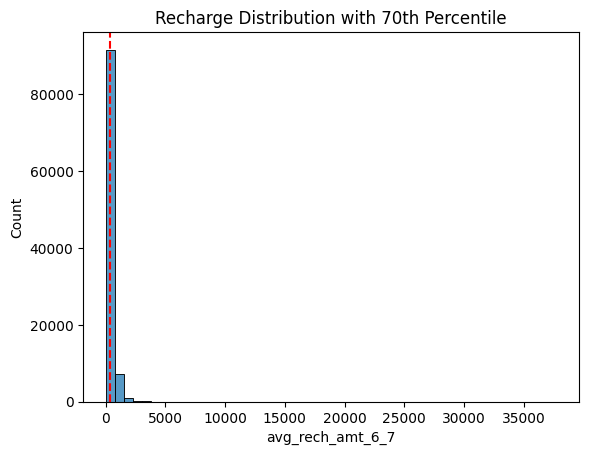

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['avg_rech_amt_6_7'], bins=50)
plt.axvline(threshold, color='red', linestyle='--')
plt.title("Recharge Distribution with 70th Percentile")
plt.show()